In [4]:
import torch
import torchaudio
import librosa
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from torchaudio.models import Conformer, RNNT
from torchaudio.pipelines import RNNTBundle
import torch.nn.functional as F
import IPython.display as ipd
import soundfile as sf
from torchviz import make_dot
import os


In [5]:
def load_audio(file_path, target_sr=16000):
    speech, sr = librosa.load(file_path, sr=target_sr)
    return torch.tensor(speech).unsqueeze(0), sr

In [6]:

file_path = "LJ001-0031.wav"
waveform, sample_rate = load_audio(file_path)

In [ ]:
def infer_wav2vec2(waveform):
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
    model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
    input_values = processor(waveform.squeeze(), return_tensors="pt", sampling_rate=16000).input_values
    with torch.no_grad():
        logits = model(input_values).logits
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.decode(predicted_ids[0])
    return transcription, model

wav2vec2_output, wav2vec2_model = infer_wav2vec2(waveform)


In [8]:
print(wav2vec2_output)

IN FOURTEEN SIXTY FIVE SWAYNHEIM AND PANARCHS BEGAN PRINTING IN THE MONASTERY OF SUBIACO NEAR ROME


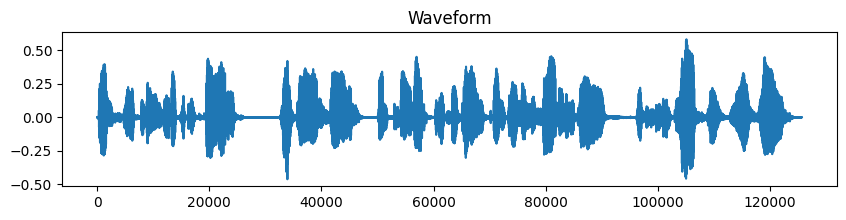

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

/usr/local/lib/python3.11/dist-packages/transformers/models/wav2vec2/modeling_wav2vec2.py:870: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if attn_output.size() != (bsz, self.num_heads, tgt_len, self.head_dim):


ONNX model saved as 'wav2vec2.onnx'


In [10]:
import torch
import torchaudio
import matplotlib.pyplot as plt
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from torchviz import make_dot
from jiwer import wer

audio_path = "/content/LJ001-0031.wav"
waveform, sample_rate = torchaudio.load(audio_path)

if sample_rate != 16000:
    waveform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)(waveform)
    sample_rate = 16000

plt.figure(figsize=(10, 2))
plt.plot(waveform.t().numpy())
plt.title("Waveform")
plt.show()

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h").eval()
print(model)

inputs = processor(waveform.squeeze().numpy(), sampling_rate=sample_rate, return_tensors="pt", padding=True)
with torch.no_grad():
    logits = model(**inputs).logits

pred_ids = torch.argmax(logits, dim=-1)
transcription = processor.decode(pred_ids[0])
print("Transcription Output:", transcription)

reference = "Printing in the only sense with which we are at present concerned differs from most if not from all the arts and crafts represented in the Exhibition"
print("Word Error Rate (WER):", wer(reference.lower(), transcription.lower()))

dot = make_dot(logits, params=dict(list(model.named_parameters())))
dot.format = 'png'
dot.render('wav2vec2_architecture')
print("Computation graph saved as 'wav2vec2_architecture.png'")

torch.onnx.export(
    model,
    (inputs["input_values"],),
    "wav2vec2.onnx",
    input_names=["input_values"],
    output_names=["logits"],
    dynamic_axes={"input_values": {0: "batch_size", 1: "sequence"}},
    opset_version=17
)
print("ONNX model saved as 'wav2vec2.onnx'")


In [11]:
file_path = "LJ001-0031.wav"
waveform, sample_rate = load_audio(file_path)

100%|██████████| 3.81k/3.81k [00:00<00:00, 2.66MB/s]
100%|██████████| 293M/293M [00:01<00:00, 266MB/s]
100%|██████████| 295k/295k [00:00<00:00, 10.2MB/s]


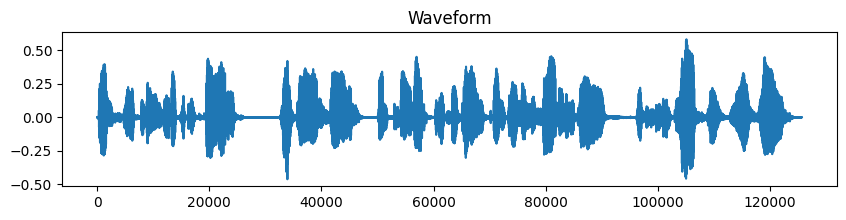

Transcription: and fourteen sixty five swayingheim and panarax began printing in the monastery of supiako near
Word Error Rate (WER): 0.9629629629629629


In [14]:
import torch
import torchaudio
import matplotlib.pyplot as plt
from torchaudio.pipelines import EMFORMER_RNNT_BASE_LIBRISPEECH
from jiwer import wer

# Load Emformer RNN-T pipeline components
bundle = EMFORMER_RNNT_BASE_LIBRISPEECH
feature_extractor = bundle.get_feature_extractor()
decoder = bundle.get_decoder()
token_processor = bundle.get_token_processor()

# Load and preprocess audio
audio_path = "/content/LJ001-0031.wav"
waveform, sr = torchaudio.load(audio_path)
if sr != 16000:
    waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

# Visualize waveform
plt.figure(figsize=(10, 2))
plt.plot(waveform[0].numpy())
plt.title("Waveform")
plt.show()

# Prepare waveform and extract features
waveform = waveform.squeeze(0)
with torch.no_grad():
    features, lengths = feature_extractor(waveform)

# Decode and process output
hypotheses = decoder(features, lengths, beam_width=10)
transcription = token_processor(hypotheses[0][0])
print("Transcription:", transcription)

# Compute WER
reference = "Printing in the only sense with which we are at present concerned differs from most if not from all the arts and crafts represented in the Exhibition"
print("Word Error Rate (WER):", wer(reference.lower(), transcription.lower()))
